<a href="https://colab.research.google.com/github/salsabilarg/Water_potability_apk/blob/main/Aplikasi_Prediksi_Kelayakan_Air_Minum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**<h2>Prediksi Kelayakan Air Minum</h2>**


In [ ]:
#Install library
!pip install imbalanced-learn xgboost -q

1. Load Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

df = pd.read_csv('water_potability.csv')
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


2. EDA (Exploratory Data Analysis)

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing/len(df)*100).round(2)
print(pd.DataFrame({"Jumlah": missing, "Persentase (%)": missing_pct}))

n_dupe = df.duplicated().sum()
print(f"\nDuplikat: {n_dupe} baris ({n_dupe/len(df)*100:.2f}%)")

                 Jumlah  Persentase (%)
ph                  491           14.99
Hardness              0            0.00
Solids                0            0.00
Chloramines           0            0.00
Sulfate             781           23.84
Conductivity          0            0.00
Organic_carbon        0            0.00
Trihalomethanes     162            4.95
Turbidity             0            0.00
Potability            0            0.00

Duplikat: 0 baris (0.00%)


In [ ]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


Potability
0    1998
1    1278
Name: count, dtype: int64
Potability
0    60.989011
1    39.010989
Name: proportion, dtype: float64


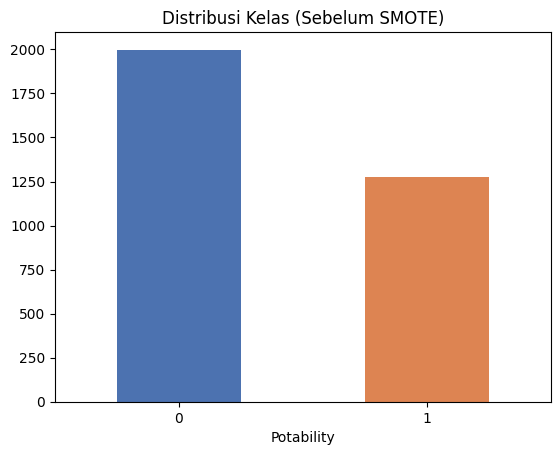

In [ ]:
print(df["Potability"].value_counts())
print(df["Potability"].value_counts(normalize=True)*100)

df["Potability"].value_counts().plot(kind="bar", color=["#4C72B0","#DD8452"])
plt.title("Distribusi Kelas (Sebelum SMOTE)")
plt.xticks(rotation=0)
plt.show()

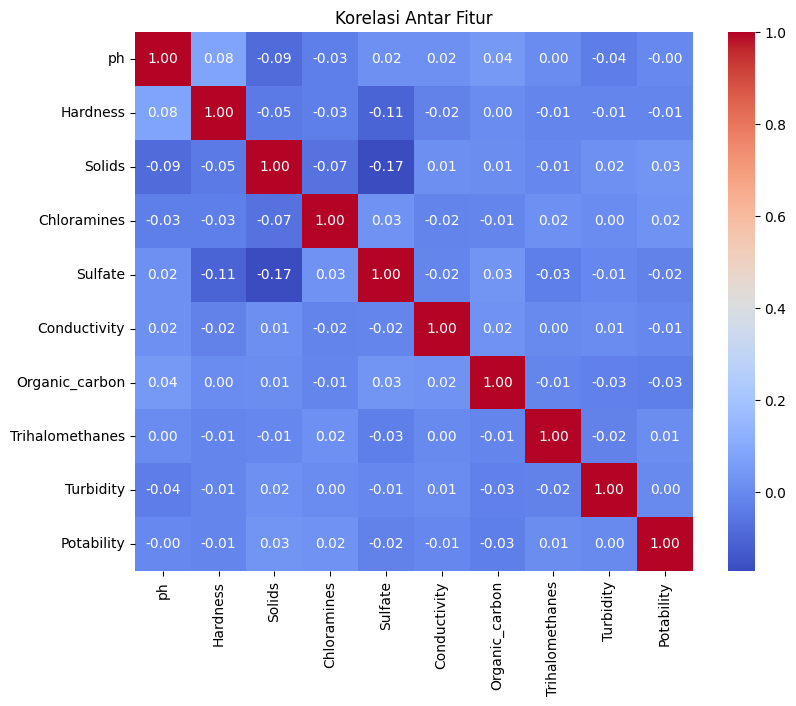

Potability         1.000000
Solids             0.033743
Chloramines        0.023779
Trihalomethanes    0.007130
Turbidity          0.001581
ph                -0.003556
Conductivity      -0.008128
Hardness          -0.013837
Sulfate           -0.023577
Organic_carbon    -0.030001
Name: Potability, dtype: float64


In [ ]:
corr = df.corr()
plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelasi Antar Fitur")
plt.show()

print(corr["Potability"].sort_values(ascending=False))

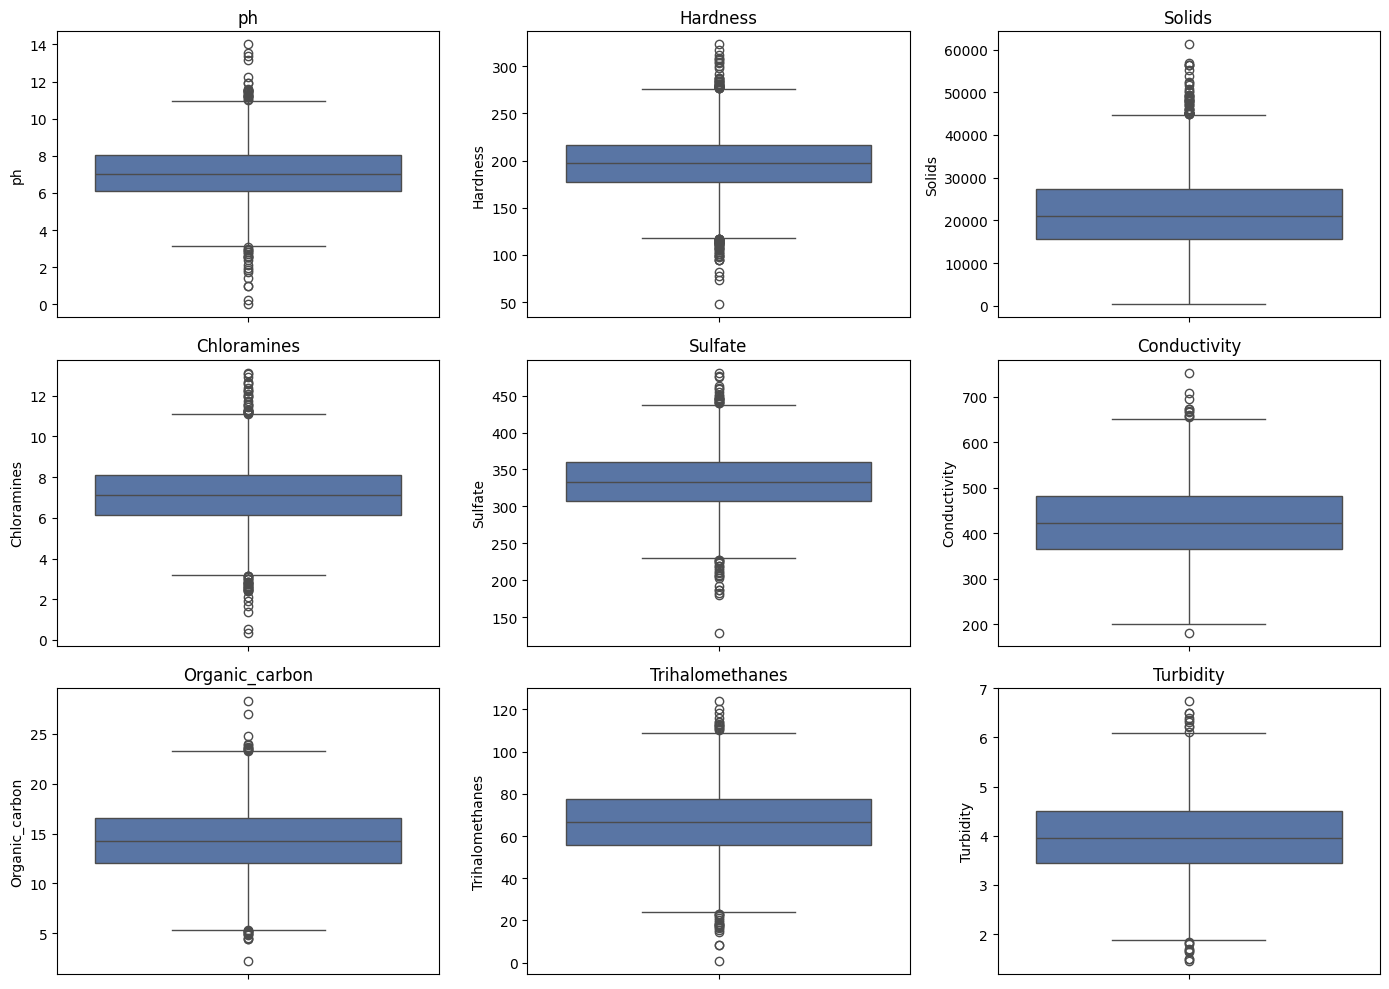

In [ ]:
# Cek outlier tiap fitur
fig, axes = plt.subplots(3, 3, figsize=(14,10))
for ax, col in zip(axes.flatten(), df.columns[:-1]):
    sns.boxplot(y=df[col], ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()
plt.show()

3. Data Cleaning

In [ ]:
df_clean = df.copy()

cols_missing = ["ph", "Sulfate", "Trihalomethanes"]
for col in cols_missing:
    df_clean[col] = df_clean.groupby("Potability")[col].transform(lambda x: x.fillna(x.median()))

df_clean = df_clean.drop_duplicates()
print("Cek ulang missing value:")
print(df_clean.isnull().sum())

Cek ulang missing value:
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


4. Split Data & Feature Scaling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_clean.drop("Potability", axis=1)
y = df_clean["Potability"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data training:", X_train.shape[0], "| Data testing:", X_test.shape[0])

NameError: name 'df_clean' is not defined

5. Cek Imbalance & SMOTE

Sebelum SMOTE:
Potability
0    1598
1    1022
Name: count, dtype: int64

Sesudah SMOTE:
Potability
0    1598
1    1598
Name: count, dtype: int64


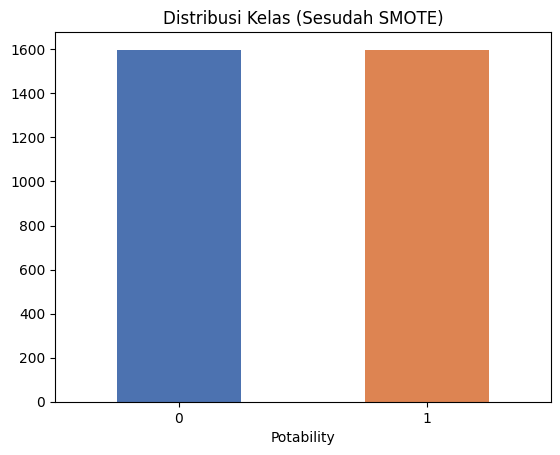

In [ ]:
from imblearn.over_sampling import SMOTE

print("Sebelum SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("\nSesudah SMOTE:")
print(pd.Series(y_train_sm).value_counts())

pd.Series(y_train_sm).value_counts().plot(kind="bar", color=["#4C72B0","#DD8452"])
plt.title("Distribusi Kelas (Sesudah SMOTE)")
plt.xticks(rotation=0)
plt.show()

6. Training & Perbandingan Beberapa Algoritma

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, roc_auc_score, confusion_matrix,
                              accuracy_score, precision_score, recall_score, f1_score)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42),
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })
    trained_models[name] = model
    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=["Tidak Layak","Layak Minum"]))

results_df = pd.DataFrame(results).sort_values("F1-Score", ascending=False)
results_df

--- Logistic Regression ---
              precision    recall  f1-score   support

 Tidak Layak       0.65      0.52      0.58       400
 Layak Minum       0.43      0.56      0.48       256

    accuracy                           0.54       656
   macro avg       0.54      0.54      0.53       656
weighted avg       0.56      0.54      0.54       656

--- Random Forest ---
              precision    recall  f1-score   support

 Tidak Layak       0.81      0.83      0.82       400
 Layak Minum       0.72      0.70      0.71       256

    accuracy                           0.78       656
   macro avg       0.77      0.76      0.76       656
weighted avg       0.78      0.78      0.78       656

--- SVM ---
              precision    recall  f1-score   support

 Tidak Layak       0.69      0.68      0.69       400
 Layak Minum       0.52      0.54      0.52       256

    accuracy                           0.62       656
   macro avg       0.60      0.61      0.61       656
weighted avg

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
4,XGBoost,0.786585,0.724806,0.730469,0.727626,0.869521
1,Random Forest,0.777439,0.721774,0.699219,0.710317,0.875820
2,SVM,0.621951,0.515038,0.535156,0.524904,0.649316
0,Logistic Regression,0.536585,0.428144,0.558594,0.484746,0.550127
3,KNN,0.576220,0.460714,0.503906,0.481343,0.606934


7. Memilih Model Terbaik & Save

In [ ]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
print("Model terbaik:", best_model_name)

joblib.dump(best_model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

median_values = {col: float(df_clean[col].median()) for col in cols_missing}
joblib.dump(median_values, "median_imputasi.pkl")
print("Median imputasi:", median_values)

from google.colab import files
files.download("model.pkl")
files.download("scaler.pkl")
files.download("median_imputasi.pkl")

Model terbaik: XGBoost
Median imputasi: {'ph': 7.035455515887571, 'Sulfate': 333.38942610169323, 'Trihalomethanes': 66.54219804427565}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>